# Example 4 — Mission Phase Transition and Attitude Control

This example demonstrates a multi-phase mission for SC1. The spacecraft begins in a translational phase and transitions to a phase containing guidance, navigation, attitude control, RCS actuation, and high-rate rotational/translational propagation.

The code below preserves the original example. The surrounding Markdown cells document the purpose and role of each part of the simulation.

In [1]:
import numpy as np
from pathlib import Path
import sys

path = Path.cwd()

REPO_ROOT = path.parents[1]

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

### Environment

The environment object provides the simulation environment in which the spacecraft dynamics are evaluated.

In [2]:
# Define the environment
from py.modules.controllers.basic_laws import BasicRCSAllocator
from py.modules.enviroments.environments import ClassicalEnvironment

env = ClassicalEnvironment() # NOTE: Need to review for proper implmentation of the environment class

### Propagators

The propagator defines the dynamical model and numerical integration method used by the simulation.

In [3]:
# Then, define the propagatorss
from py.modules.propagators.native_propagator import NativeTranslationalPropagator
translational_propagator2 = NativeTranslationalPropagator(dynamics="REL2BP", integration_method="NATIVE_RK45")

sim_max_time = 60*15  # 5 minutes in seconds

from py.modules.new.simulation import Simulation
sim = Simulation(max_sim_time=sim_max_time,                 
                 environment= env,                 
                 verbose = True
)

dt1 = 20.0  # Propagation update every 10 seconds
dt2 = 10.0  # Propagation update every 10 seconds

from py.modules.sensors.generic_sensor import AbsoluteSensor

sensors2 = [AbsoluteSensor(1/dt2, verbose=False)]  # Sample rate of 100 Hz

from py.modules.navigation.basic_laws import IdealNavigation
from py.general.dataclasses import MissionPhase
from py.modules.new.mission_manager import MissionManager

nav_law = IdealNavigation()
nav_law2 = IdealNavigation()


phase2 = MissionPhase(
    name="Phase 1",
    navigation=nav_law2,
    dt_nav=dt2,  # Navigation update every 1 second
    dt_propagation=dt2,  # Propagation update every 10 seconds
    translational_model=translational_propagator2
)

mission_manager2 = MissionManager(
    initial_phase=phase2
) 

initial_position_SC2 = np.array([0, 7000e3, 0])  # Initial position in meters
initial_velocity_SC2 = np.array([7.5e3, 0, 0])

sim.add_spacecraft(
    name="SC2",
    initial_position=initial_position_SC2,
    initial_velocity=initial_velocity_SC2,
    sensors=sensors2,
    mission_manager=mission_manager2,
)

initial_position_SC1 = np.array([7000e3, 0, 3500e3])  # Initial position in meters
initial_velocity_SC1 = np.array([0, 7.5e3, 0])
initial_attitude = np.array([0, 0, 0, 1])  # Initial quaternion
initial_angular_velocity = np.array([0, 0, 0])  # Initial angular velocity in rad/s




from py.modules.actuators.RCS import RCSThruster

thruster_X_pos = RCSThruster(
    nominal_thrust= 1 ,# Newtons, placeholder value
    direction= np.array([1, 0, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_X_neg = RCSThruster(
    nominal_thrust= 1 ,# Newtons, placeholder value
    direction= np.array([-1, 0, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
    
)

thruster_Y_pos = RCSThruster(
    nominal_thrust= 1 ,# Newtons, placeholder value
    direction= np.array([0, 1, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_Y_neg = RCSThruster(
    nominal_thrust= 1 ,# Newtons, placeholder value
    direction= np.array([0, -1, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_Z_pos = RCSThruster(
    nominal_thrust= 1 ,# Newtons, placeholder value
    direction= np.array([0, 0, 1]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0   
)

thruster_Z_neg = RCSThruster(
    nominal_thrust= 1 ,# Newtons, placeholder value
    direction= np.array([0, 0, -1]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thrusters = [thruster_X_pos, thruster_X_neg, thruster_Y_pos, thruster_Y_neg, thruster_Z_pos, thruster_Z_neg]
sensors = [AbsoluteSensor(100, verbose=False), AbsoluteSensor(100, verbose=False) ]  # Sample rate of 100 Hz

from py.modules.propagators.native_propagator import NativeRotationalPropagator

translational_propagator = NativeTranslationalPropagator(dynamics="REL2BP", integration_method="NATIVE_RK45")
nav_law = IdealNavigation()
nav_law_phase2 = IdealNavigation(sensor_to_be_use=2)  # Use the second AbsoluteSensor for phase 2

phase = MissionPhase(
    name="Phase 1",
    navigation=nav_law_phase2,
    dt_nav=dt1,  # Navigation update every 1 second
    translational_model=translational_propagator,
    dt_propagation= dt1  # Propagation update every 1 second
)



from py.modules.guidance.basic_laws import ConstantReferenceGuidance
from py.modules.math import quaternion_from_euler
objective_orientation = [0, 0, 0]  # Desired orientation in Euler angles (degrees)
guidance_law = ConstantReferenceGuidance(
    desired_quat = quaternion_from_euler(np.deg2rad(objective_orientation[0]), np.deg2rad(objective_orientation[1]), np.deg2rad(objective_orientation[2]))
)

from py.modules.controllers.classic_controllers import PDAttitudeController

control_law = PDAttitudeController(
    proportional_gain= 1000,    
    derivative_gain= 20000,
    maximum_torque= 1000,
    minimum_torque= -1000
)

rot_propagator = NativeRotationalPropagator(integration_method="NATIVE_RK45")
translational_propagator_2 = NativeTranslationalPropagator(dynamics="REL2BP", integration_method="NATIVE_RK45")
allocator_law = BasicRCSAllocator()

sc1_phase2= MissionPhase(
    name="Phase 2",
    guidance= guidance_law,
    navigation= nav_law,
    controller= control_law,

    allocator = allocator_law,

    dt_nav = 0.1,  # Navigation update rate (10 Hz)
    dt_guid = 1,  # Guidance update rate (1 Hz)
    dt_control = 0.1, # Control update rate (10 Hz)

    rotational_model= rot_propagator,
    translational_model= translational_propagator_2,
    dt_propagation= 0.01 # Propagation time step (100 Hz)
)

mission_manager = MissionManager(
    initial_phase=phase
)

mission_manager.add_phases(sc1_phase2)

def condition_sc1_time(simulation_data) -> bool:

    for spacecraft in simulation_data.spacecrafts:

        if spacecraft.name == "SC1":
            return spacecraft.spacecraft_data.t >= (sim_max_time - (300))  # Transition after half of the simulation time

    return False


mission_manager.add_transition(
    from_phase=phase,
    target_phase=sc1_phase2,
    condition=condition_sc1_time
)


initial_orientation = initial_orientation = [45, -30, -10]  # Initial orientation in Euler angles (degrees)
initial_orientation_quat = quaternion_from_euler(np.deg2rad(initial_orientation[0]), np.deg2rad(initial_orientation[1]), np.deg2rad(initial_orientation[2]))
initial_angular_velocity = np.array([-0.08, 0.05, 0.1])  # Initial angular velocity in rad/s

from py.general.general_data import Ix_total, Iy_total, Iz_total

inertia_tensor=np.diag([
    Ix_total,
    Iy_total,
    Iz_total
])

sim.add_spacecraft(
    name="SC1",
    initial_position=initial_position_SC1,
    initial_velocity=initial_velocity_SC1,
    initial_attitude=initial_orientation_quat,
    initial_angular_velocity=initial_angular_velocity,
    inertia_tensor= np.diag([Ix_total, Iy_total, Iz_total]),  # Inertia tensor in kg*m^2
    sensors=sensors,
    mission_manager=mission_manager,    
    actuators=thrusters,
)

Spacecraft 'SC2' added to the simulation.
Spacecraft 'SC1' added to the simulation.


### Simulation execution and results

The configured simulation is executed and its results are passed to the visualization utilities.

Initializing simulation...
Spacecraft 'SC2' dt_nav: 10.0, dt_guid: nan, dt_control: nan
Spacecraft 'SC1' dt_nav: 20.0, dt_guid: nan, dt_control: nan
Simulation initialized.
Starting simulation...
Spacecraft 'SC2' dt_nav: 10.0, dt_guid: nan, dt_control: nan
Spacecraft 'SC1' dt_nav: 0.1, dt_guid: 1, dt_control: 0.1
Simulation completed.


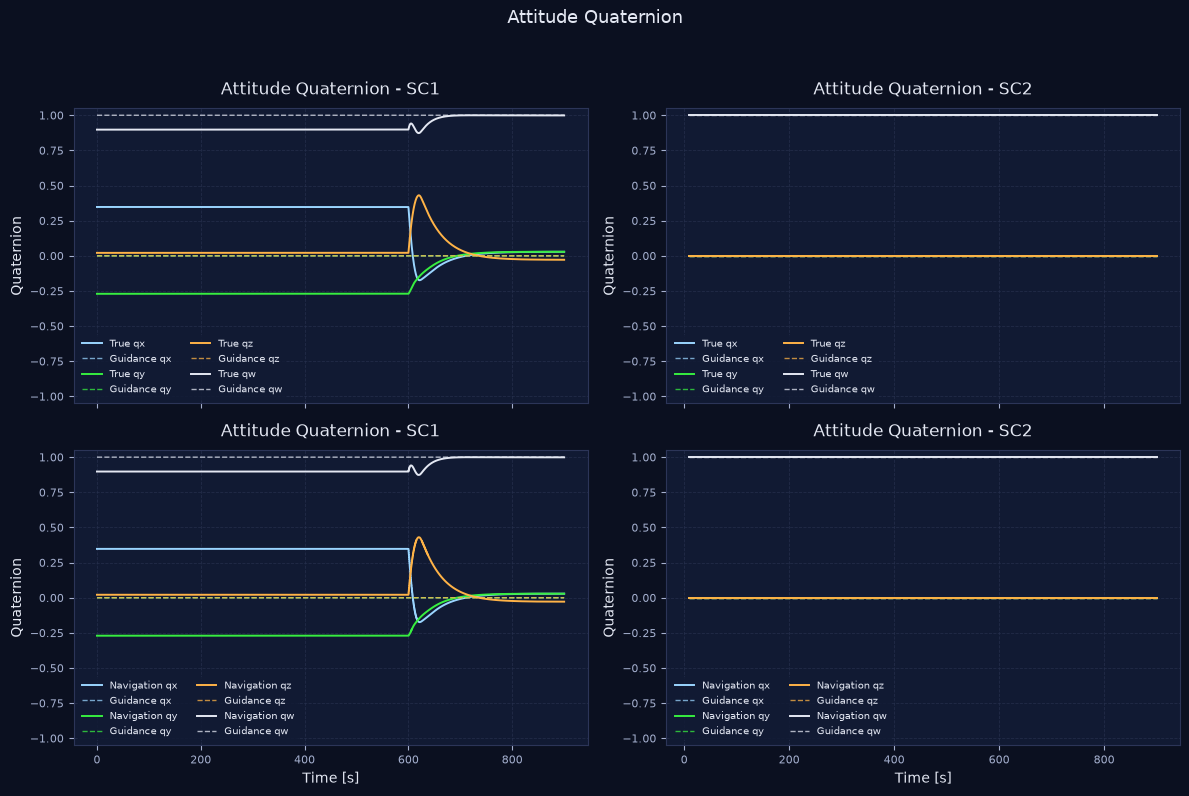

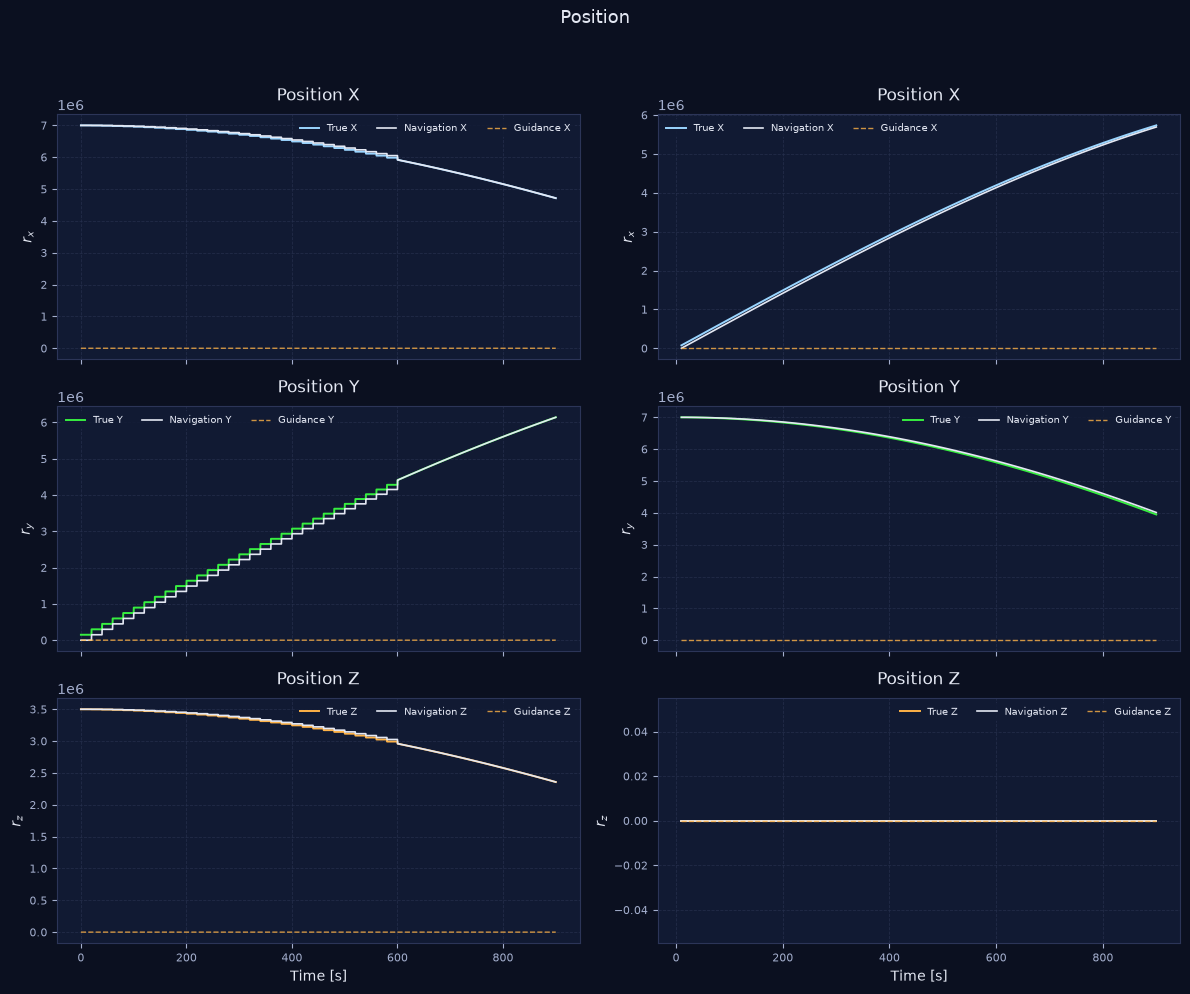

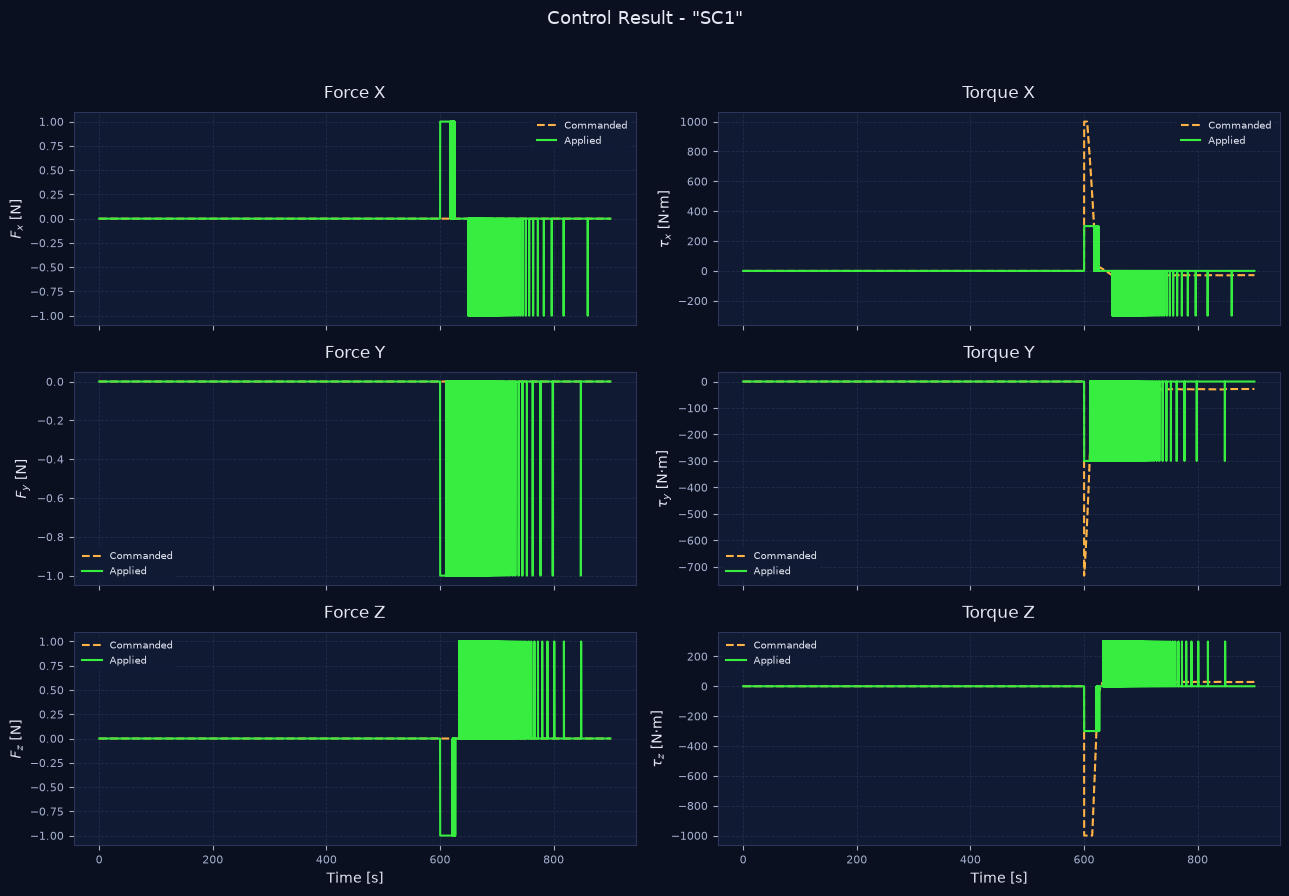

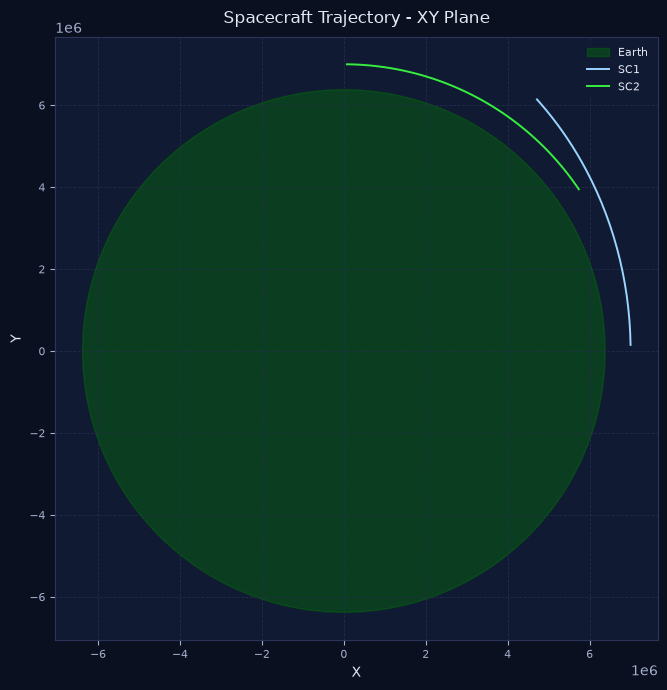

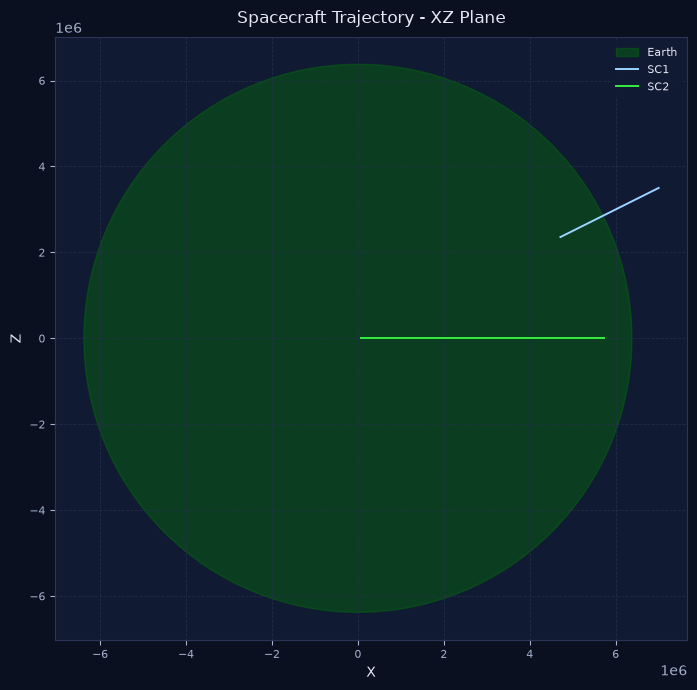

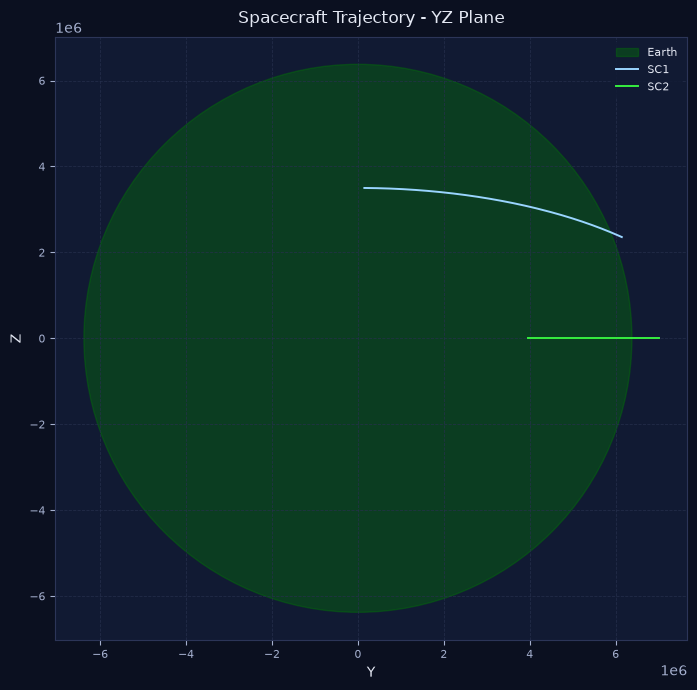

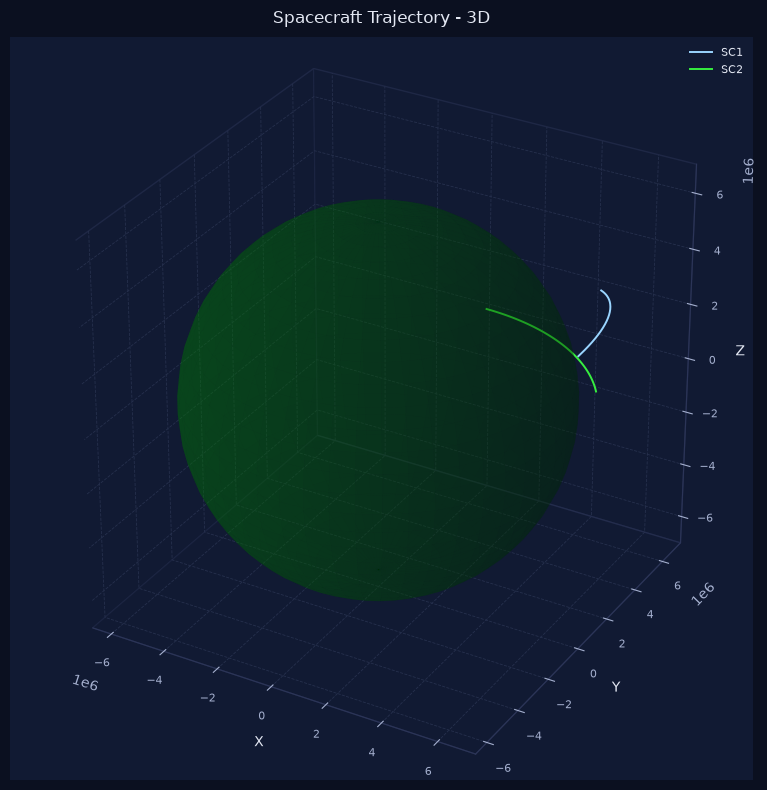

/home/afra/Documents/repos/ARGOS-Toolkit/py/modules/visualization/trajectories.py:1292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


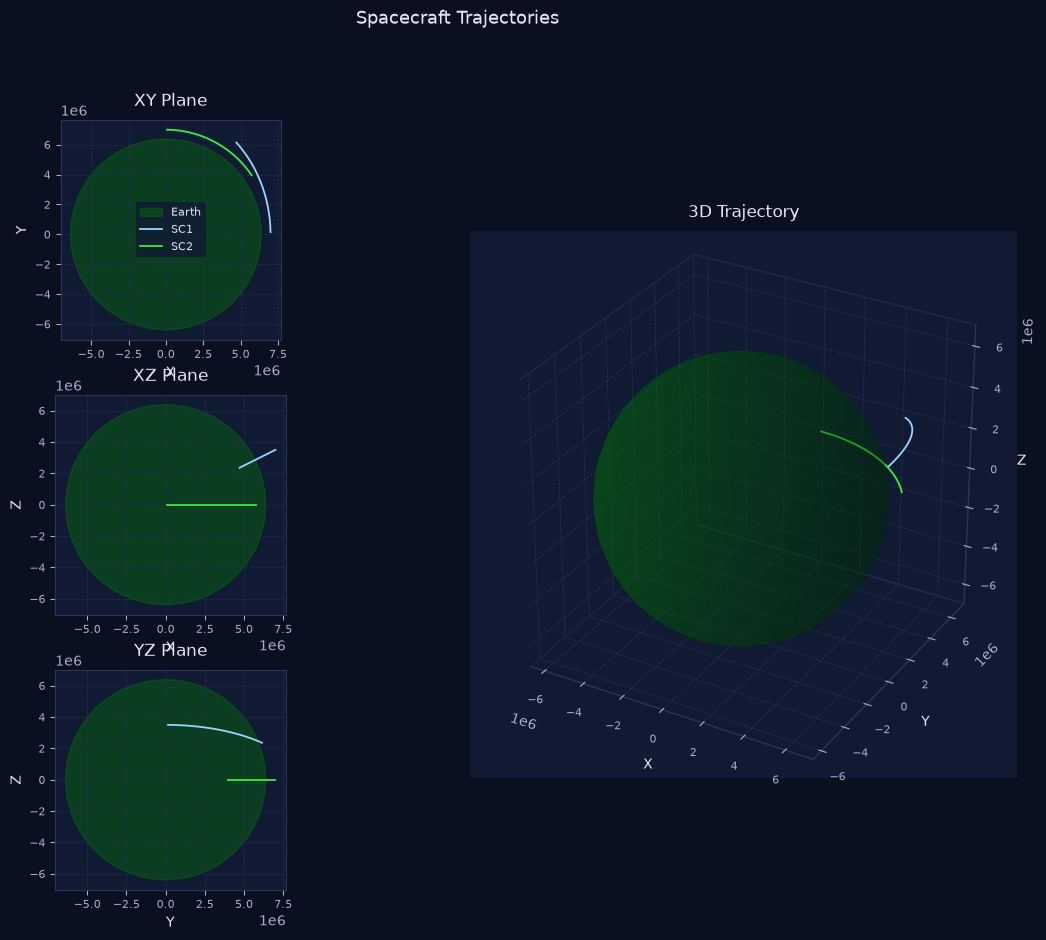

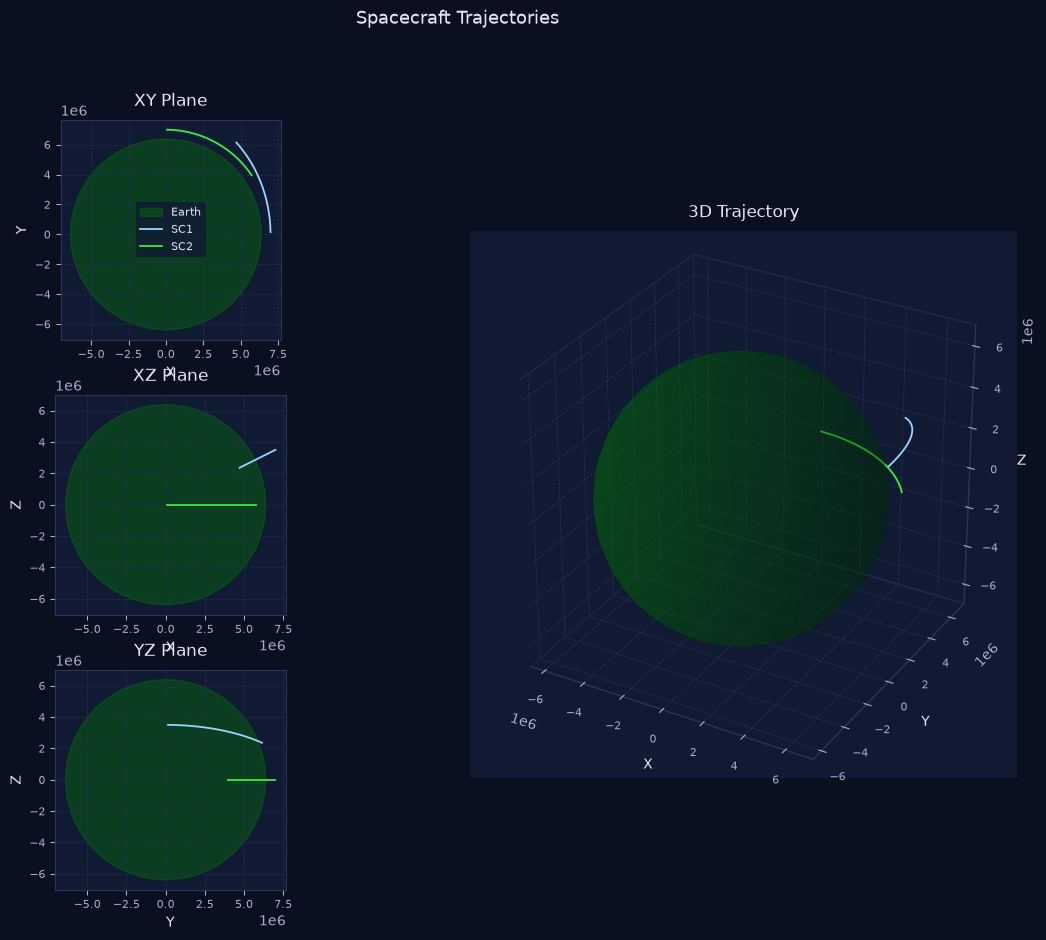

In [4]:
# We can now simulate
result = sim.simulate()


from py.modules.visualization.state_variables import plot_attitude_quaternions, plot_position

plot_attitude_quaternions(["SC1", "SC2"], result, show=True)
plot_position(["SC1", "SC2"], result, show=True)


from py.modules.visualization.control import plot_control_result
plot_control_result("SC1", result)

from py.modules.visualization.trajectories import *

plot_trajectory_xy(["SC1", "SC2"], result, show=True, body="Earth",)
plot_trajectory_xz(["SC1", "SC2"], result, show=True, body="Earth",)
plot_trajectory_yz(["SC1", "SC2"], result, show=True, body="Earth",)
plot_trajectory_3d(["SC1", "SC2"], result, show=True, body="Earth",)
plot_trajectory(["SC1", "SC2"], result, show=True, body="Earth",)

### Example scope

This notebook documents the example as provided. No simulation logic, parameters, class usage, or numerical values have been changed during conversion.